mean reward = -89.216, threshold=6.000


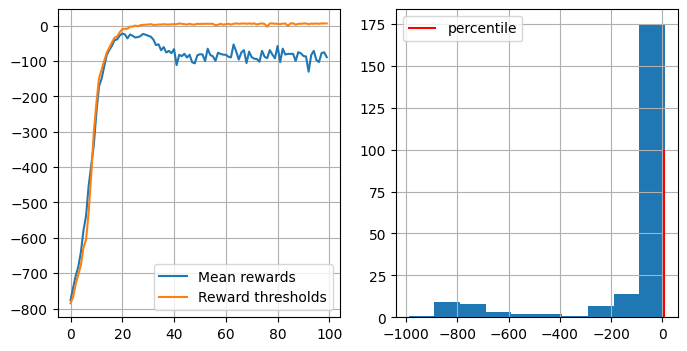

In [1]:
# 1. Инициализация среды.
import sys, os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import clear_output

env = gym.make("Taxi-v3")
env.reset()
n_states = env.observation_space.n
n_actions = env.action_space.n
print("n_states=%i, n_actions=%i" % (n_states, n_actions))

# 2. Создание стохастической политики
def initialize_policy(n_states, n_actions):
    policy = np.ones((n_states, n_actions)) / n_actions
    return policy

policy = initialize_policy(n_states, n_actions)

assert type(policy) in (np.ndarray, np.matrix)
assert np.allclose(policy, 1./n_actions)
assert np.allclose(np.sum(policy, axis=1), 1)

# 3. Игра с моделью
def generate_session(env, policy, t_max=10**4):
    """
    Играть до конца или t_max тиков.
    :param policy: массив вида [n_states,n_actions] с вероятностями действий
    :returns: список состояний, список действий и сумма наград
    """
    states, actions = [], []
    total_reward = 0.

    s, _ = env.reset()

    for t in range(t_max):
        a = np.random.choice(n_actions, p=policy[s])

        new_s, r, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        states.append(s)
        actions.append(a)
        total_reward += r
        s = new_s

        if done:
            break

    return states, actions, total_reward

s, a, r = generate_session(env, policy)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]

sample_rewards = [generate_session(env, policy, t_max=1000)[-1] for _ in range(200)]

plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="50'th percentile", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90'th percentile", color='red')
plt.legend()
plt.show()

# 4. Шаги кросс-энтропийного метода
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Выберите состояния и действия из игры, которые имеют награды >= процентиль
    """
    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []

    for i in range(len(states_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions

states_batch = [[1,2,3], [4,2,0,2], [3,1]]
actions_batch = [[0,2,4], [3,2,0,1], [3,3]]
rewards_batch = [3,4,5]

test_result_0 = select_elites(states_batch, actions_batch, rewards_batch, percentile=0)
test_result_30 = select_elites(states_batch, actions_batch, rewards_batch, percentile=30)
test_result_90 = select_elites(states_batch, actions_batch, rewards_batch, percentile=90)
test_result_100 = select_elites(states_batch, actions_batch, rewards_batch, percentile=100)

assert np.all(test_result_0[0] == [1,2,3,4,2,0,2,3,1]) and np.all(test_result_0[1] == [0,2,4,3,2,0,1,3,3])
assert np.all(test_result_30[0] == [4,2,0,2,3,1]) and np.all(test_result_30[1] == [3,2,0,1,3,3])
assert np.all(test_result_90[0] == [3,1]) and np.all(test_result_90[1] == [3,3])
assert np.all(test_result_100[0] == [3,1]) and np.all(test_result_100[1] == [3,3])

def get_new_policy(elite_states, elite_actions):
    """

    Учитывая список лучших состояний/действий от select_elites,
    возвращает новую политику
    """
    new_policy = np.zeros([n_states, n_actions])

    for state, action in zip(elite_states, elite_actions):
        new_policy[state, action] += 1

    for state in range(n_states):
        if np.sum(new_policy[state]) > 0:
            new_policy[state] = new_policy[state] / np.sum(new_policy[state])
        else:
            new_policy[state] = np.ones(n_actions) / n_actions

    return new_policy

# 5. Тренировочный цикл
def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    Удобная функция, отображающая прогресс обучения
    """
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label='Mean rewards')
    plt.plot(list(zip(*log))[1], label='Reward thresholds')
    plt.legend()
    plt.grid()
    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines([np.percentile(rewards_batch, percentile)],
    [0], [100], label="percentile", color='red')
    plt.legend()
    plt.grid()
    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()

policy = initialize_policy(n_states, n_actions)

n_sessions = 250
percentile = 50
learning_rate = 0.5
log = []

for i in range(100):
    sessions = [generate_session(env, policy) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    new_policy = get_new_policy(elite_states, elite_actions)
    policy = learning_rate * new_policy + (1 - learning_rate) * policy
    show_progress(rewards_batch, log, percentile)


**Анализ сходимости задачи такси**

В начале средняя награда находится на уровне менее -1000. Это объясняется тем, что случайная политика выполняет множество неправильных действий (посадка/высадка в неверных местах), получая штраф -10 за каждую ошибку и -1 за каждый шаг.

Далее награды быстро достигают пика. Агент научается правильно выполнять заказ: ехать к пассажиру, подбирать, ехать к цели
В конце наблюдается снижение производительности.

Политика стала слишком детерминированной, происходит переобучение. Агент перестал исследовать новые состояния. Если в неисследованных состояниях политика неоптимальна, агент застревает или делает лишние шаги.

CEM быстро учится на удачных траекториях, но без исследования со временем деградирует.
